In [1]:
import glob
import json
import os

from dotenv import load_dotenv
# use pip install "labelbox[data]"
from labelbox import Client

from koger_detection.labelbox.annotations import download_annotation_projects

# Load local .env file that contains local path "ROOT" and "LABELBOX_API_KEY"
load_dotenv()

True

In [2]:
project_names = ["high-altitude-pronghorn-survey"]
# print(*project_names, sep="\n")

research_project = "pronghorn-survey"
annotation_folder = os.path.join(os.environ.get("ROOT"), "annotations", research_project)

client = Client(api_key=os.environ.get("LABELBOX_API_KEY"))

In [3]:
if True:
    download_annotation_projects(annotation_folder, client, project_names, 
                                 verbose=True, download_images=True, 
                                 skip_existing=False)


Data Rows Converted into a COCO Dataset.

Converting Annotations into the COCO Format...



2435it [00:00, 617219.45it/s]


Annotation Conversion Complete. Converted 2435 annotations into the COCO Format.

Converting the Ontology into the COCO Dataset Format...

Ontology Conversion Complete

COCO Conversion Complete
Annotation file downloaded.
Starting to save 1221 images.


## Combine pronghorn and other ungulate class

In [4]:
from koger_detection.utils.json import rename_categories

In [5]:
category_mapping = {"cattle": "cattle",
                    "pronghorn": "pronghorn",
                    "other-ungulate": "pronghorn",
                    "hard-negative": "cattle"}

in_json_file = os.path.join(annotation_folder, "high-altitude-pronghorn-survey.json")
out_json_file = os.path.join(annotation_folder, "high-altitude-pronghorn-survey-just-ph.json")
with open(in_json_file, "r") as read_file:
    json_dict = json.load(read_file)
    
new_coco = rename_categories(json_dict, category_mapping, out_json_file)

## Split annotations into train and val set

In [6]:
from koger_detection.utils.json import create_train_val_split
from koger_detection.utils.box_coco_utils import print_instances_class_histogram

In [7]:
# just use the actual pond pictures for validation

In [8]:
json_file = os.path.join(annotation_folder, "high-altitude-pronghorn-survey-just-ph.json")
fraction_val = .15

train_name = "train-pr527-pr412-pr351.json"
val_name = "val-pr527-pr412-pr351.json"

# TO DO: Add a date stamp to train and val file names to make unique
create_train_val_split(json_file, fraction_val, train_name=train_name, 
                       val_name=val_name, stochastic=True)

There are 1221 annotated images.
1044 training images with 2059 annotations.
177 validation images with 376 annotations.


In [10]:
json_file = os.path.join(annotation_folder, train_name)

with open(json_file) as f:
    json_dict = json.load(f)

print("---------- Training --------------")
print_instances_class_histogram(json_dict, num_frames=False)

json_file = os.path.join(annotation_folder, val_name)

with open(json_file) as f:
    json_dict = json.load(f)

print("---------- Validation --------------")
print_instances_class_histogram(json_dict, num_frames=False)

---------- Training --------------
|  category  | #instances   |  category  | #instances   |
|:----------:|:-------------|:----------:|:-------------|
|   cattle   | 195          | pronghorn  | 1864         |
|            |              |            |              |
|   total    | 2059         |            |              |
---------- Validation --------------
|  category  | #instances   |  category  | #instances   |
|:----------:|:-------------|:----------:|:-------------|
|   cattle   | 28           | pronghorn  | 348          |
|            |              |            |              |
|   total    | 376          |            |              |


In [15]:
json_file = os.path.join(annotation_folder, train_name)

with open(json_file) as f:
    json_dict = json.load(f)

min_area = 1000000
bbox = None

for ann in json_dict['annotations']:
    if ann['area'] < min_area:
        min_area = ann['area']
        bbox = ann['bbox']

print(min_area)
print(bbox)


91.0
[1477, 0, 13, 7]


## Bonus: Visualize annotations

In [13]:
import os

import matplotlib.pyplot as plt

import torch
# Note: also need to install pycocotools
from torchvision import datasets
from torchvision.utils import draw_bounding_boxes
from torchvision.ops import box_convert
import torchvision.transforms.functional as F

In [14]:
example_json = os.path.join(annotation_folder, f"val.json")
image_folder = os.path.join(annotation_folder, "images")

dataset = datasets.CocoDetection(root=image_folder, annFile=example_json)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


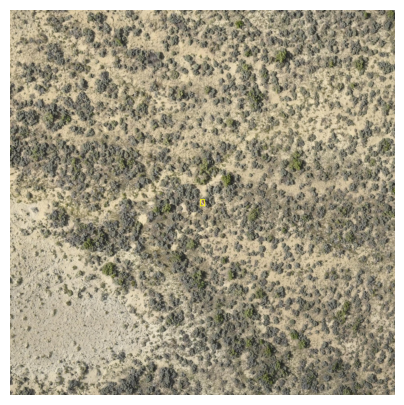

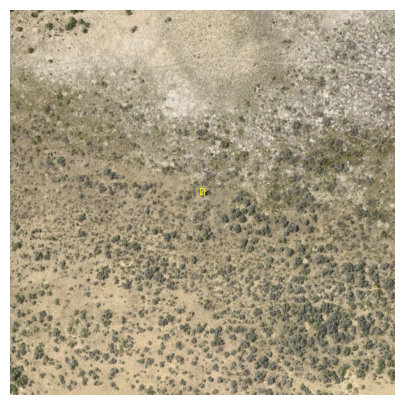

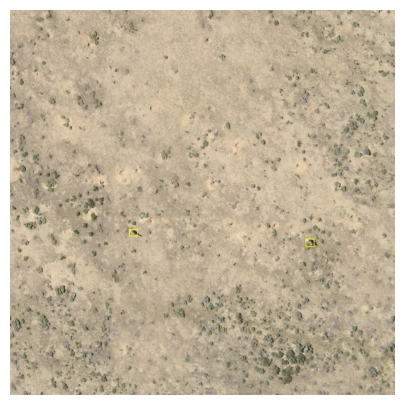

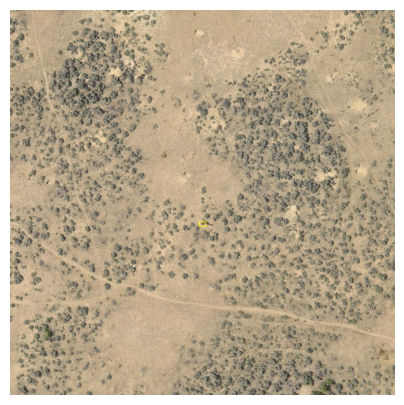

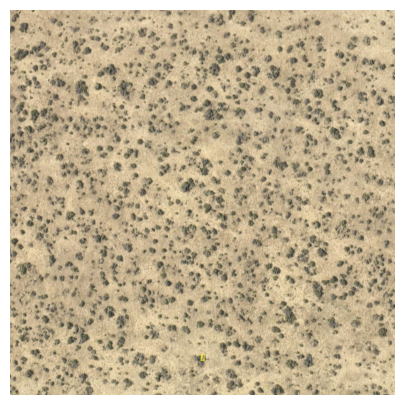

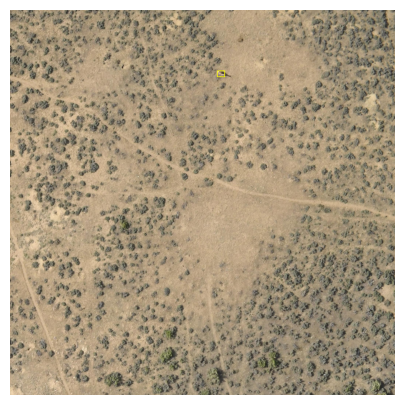

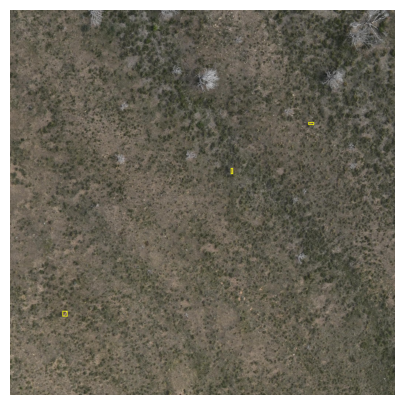

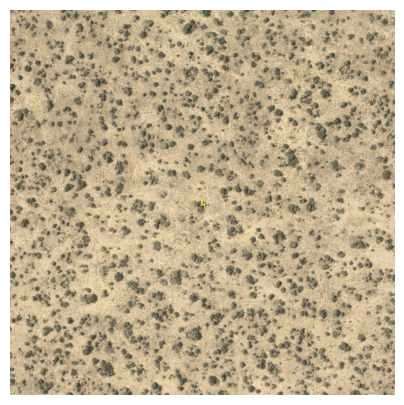

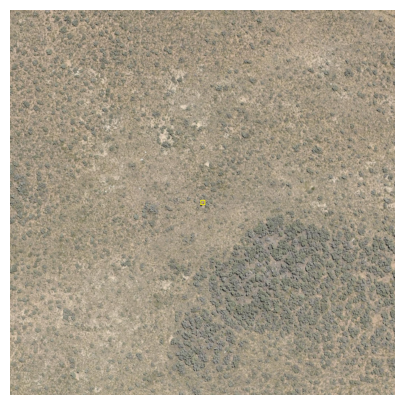

In [16]:
for im_ind in range(100, 109):
    ann = dataset[im_ind]
    if len(ann[1]) >= 1:
        boxes = torch.vstack([box_convert(torch.tensor(a['bbox']), "xywh", "xyxy") for a in ann[1]])
        labels = [a['category_id'] for a in ann[1]]
        colors = [(230,215,255), (255, 255, 0), (255, 0, 255), (255, 155, 0), (255, 0, 155),(255, 155, 155), (255, 255, 155)]
        box_colors = [colors[l-1] for l in labels]
    image = F.pil_to_tensor(ann[0])
    if len(ann[1]) >= 1:
        image = draw_bounding_boxes((image).type(torch.uint8), 
                                      boxes=boxes, colors=box_colors,
                                      width=4)
    else:
        print("No annotations")
    plt.figure(figsize=(5, 5))
    plt.imshow(F.to_pil_image(image))
    plt.axis('off')  